### Time series Analysis of weather data

#### Preparing the data

In [1]:
#importing necessary libraries to perform the timeseries analysis
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns


In [2]:
#reading the required columns from the weather.csv file
weather_df= pd.read_csv("weather.csv",usecols=["date","maxtp(Maximum Air Temperature - degrees C)"])

In [3]:
#indexing the dataframe to read only the required data 
weather_df
main_weather=weather_df.iloc[28124:]

In [4]:
main_weather.dtypes

date                                           object
maxtp(Maximum Air Temperature - degrees C)    float64
dtype: object

In [5]:
#converting the object datatype to datetime for time series analysis
main_weather['date'] = pd.to_datetime(main_weather['date'], format='%d-%b-%y')


In [6]:
#previewing the data
main_weather

,date,maxtp(Maximum Air Temperature - degrees C)
28124,2019-01-01,9.2
28125,2019-01-02,7.6
28126,2019-01-03,7.9
28127,2019-01-04,6.5
28128,2019-01-05,8.4
...,...,...
29884,2023-10-27,13.2
29885,2023-10-28,14.1
29886,2023-10-29,12.4
29887,2023-10-30,12.7


In [7]:
#Renaming the columns 
main_weather.rename(columns = {'maxtp(Maximum Air Temperature - degrees C)':'maxtp'}, inplace = True) 

In [8]:
#verifying the datatypes
main_weather.dtypes

date     datetime64[ns]
maxtp           float64
dtype: object

In [9]:
#Reset the index for the main dataframe
main_weather=main_weather.reset_index(level=None, drop=True, inplace=False, col_level=0, col_fill='')

In [10]:
#splitting the dataframe to train and test for the data between 2019 and 2022 and 2023 till end of 2023
train=main_weather.iloc[0:1461]
test=main_weather.iloc[1461:]

In [11]:
train

,date,maxtp
0,2019-01-01,9.2
1,2019-01-02,7.6
2,2019-01-03,7.9
3,2019-01-04,6.5
4,2019-01-05,8.4
...,...,...
1456,2022-12-27,11.1
1457,2022-12-28,11.3
1458,2022-12-29,9.6
1459,2022-12-30,11.4


In [12]:
test

,date,maxtp
1461,2023-01-01,6.8
1462,2023-01-02,6.1
1463,2023-01-03,13.3
1464,2023-01-04,12.6
1465,2023-01-05,12.6
...,...,...
1760,2023-10-27,13.2
1761,2023-10-28,14.1
1762,2023-10-29,12.4
1763,2023-10-30,12.7


In [13]:
#Check for nulls
train.isnull().sum()


date     0
maxtp    0
dtype: int64

In [14]:
#check for isna values
train.isna().sum()

date     0
maxtp    0
dtype: int64

In [15]:
# Output the maximum and minimum temperature date
print(train.loc[train["maxtp"] == train["maxtp"].max()])
print(train.loc[train["maxtp"] == train["maxtp"].min()])

           date  maxtp
1294 2022-07-18   29.1
           date  maxtp
705  2020-12-06    0.3
1439 2022-12-10    0.3


### Exploratory Data Analysis

Text(0.5, 1.0, 'Histogram of Max temperature')

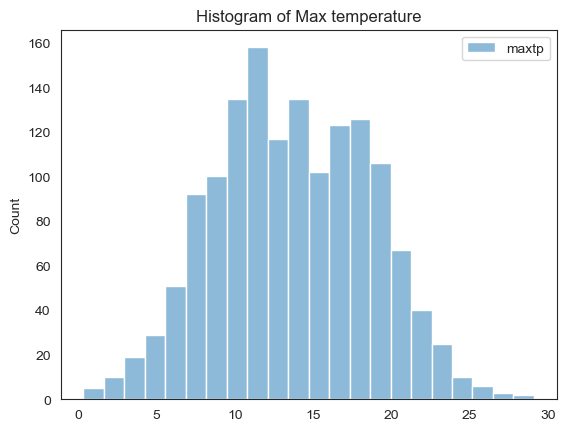

In [16]:
#histogram to check the spread of temeprature 
sns.set_style("white")
sns.histplot(train)
plt.title('Histogram of Max temperature')

Text(0.5, 0, 'Maximum Temperature')

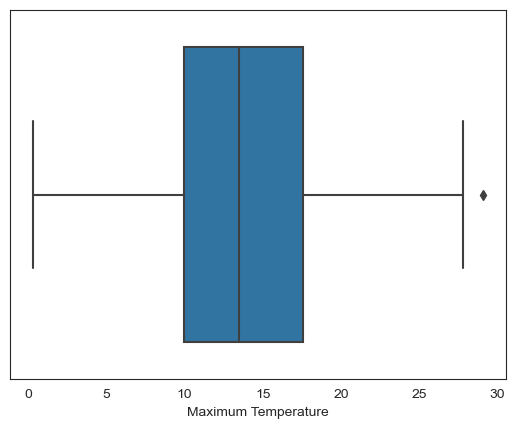

In [17]:
#box plot to check for presence of unexpected temperature captured in dataset
ax = sns.boxplot(x=train["maxtp"])
ax.set_xlabel('Maximum Temperature')

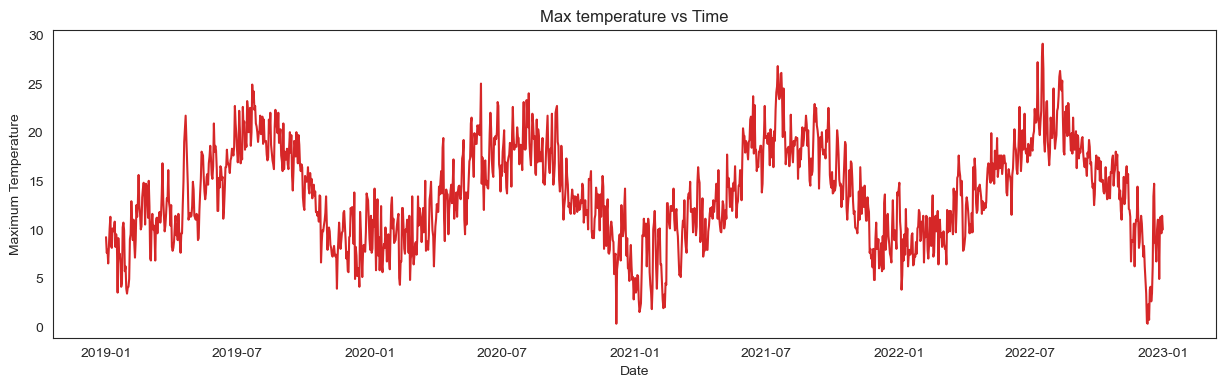

In [18]:
#Visual analysis of the maximumn air temperature of the train dataset
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Maximum Temperature', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    
plot_df(train, x=train['date'], y=train["maxtp"], title='Max temperature vs Time')

## Simple TimeSeries models

#### Mean Method

In [19]:
#implementing the mean method where the cumulative mean is captured from 2019
average_df=main_weather.copy()
average_df['avgtemp']=average_df['maxtp'].expanding().mean()
average_df=average_df.set_index('date',inplace=False)
average_df

,maxtp,avgtemp
date,,
2019-01-01,9.2,9.200000
2019-01-02,7.6,8.400000
2019-01-03,7.9,8.233333
2019-01-04,6.5,7.800000
2019-01-05,8.4,7.920000
...,...,...
2023-10-27,13.2,13.919989
2023-10-28,14.1,13.920091
2023-10-29,12.4,13.919229


In [20]:
#verifyimg the calculation for the top 10 records
average_df.head(10)

,maxtp,avgtemp
date,,
2019-01-01,9.2,9.200000
2019-01-02,7.6,8.400000
2019-01-03,7.9,8.233333
2019-01-04,6.5,7.800000
2019-01-05,8.4,7.920000
2019-01-06,10.1,8.283333
2019-01-07,11.3,8.714286
2019-01-08,8.3,8.662500
2019-01-09,8.1,8.600000


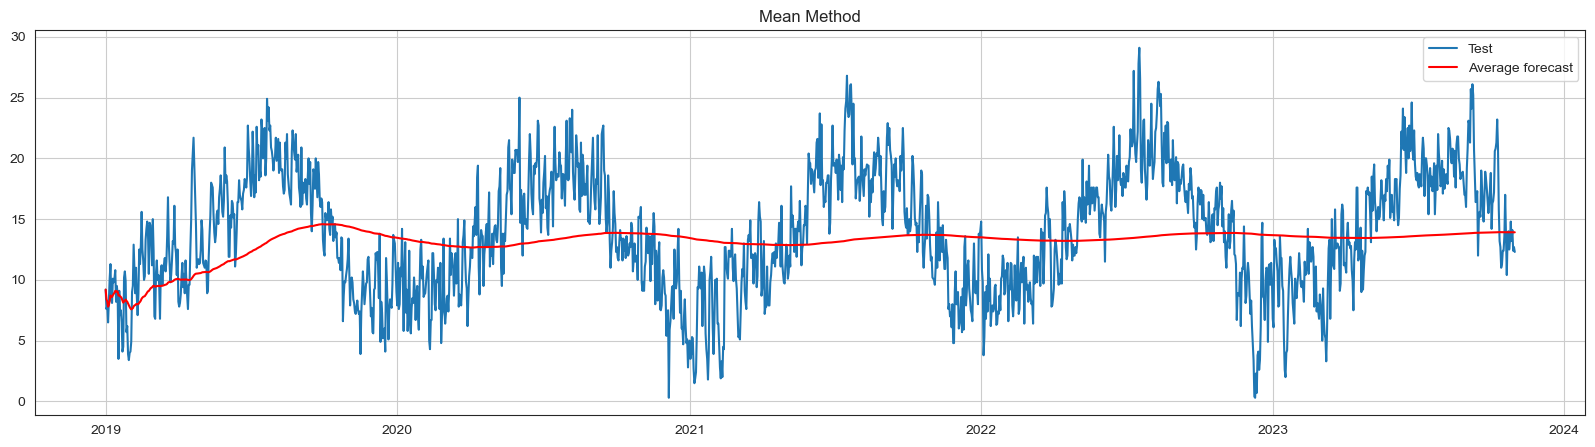

In [21]:
#Mean method curve showing the forecast
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(average_df['maxtp'], label='Test')
plt.plot(average_df['avgtemp'], label='Average forecast',color='red')
plt.legend(loc='best')
plt.title('Mean Method')
plt.show()

In [22]:
#Evaluating the fit of the mean method
maeAvg  = mean_absolute_error(average_df['maxtp'],average_df['avgtemp'])
mseAvg  = (mean_squared_error(average_df['maxtp'], average_df['avgtemp'])).round(2)
rmseAvg = np.sqrt(mean_squared_error(average_df['maxtp'],average_df['avgtemp'])).round(2)
mapeAvg = np.round(np.mean(np.abs(average_df['maxtp']-average_df['avgtemp'])/average_df['maxtp'])*100,2)

results_avg = pd.DataFrame({'Method':['Mean method'],'MAE': [maeAvg],'MSE': [mseAvg] ,'MAPE': [mapeAvg], 'RMSE': [rmseAvg]})
results_avg = results_avg[['Method','MAE' ,'MSE','RMSE', 'MAPE']]
results_avg

,Method,MAE,MSE,RMSE,MAPE
0,Mean method,4.076897,24.36,4.94,45.73


#### Naive Forecast

In [23]:
#Implementing naive forecast for the test dataset
predicted_naive_df = test["maxtp"].to_frame().shift(1).rename(columns = {"maxtp": "Naive_pred" })
actual_naive_df = test["maxtp"].to_frame().rename(columns = {"maxtp": "Naive_actual" })

# Concatenate the actual and predicted temperature
naive_df = pd.concat([test.date,actual_naive_df,predicted_naive_df],axis=1)
naive_df




,date,Naive_actual,Naive_pred
1461,2023-01-01,6.8,NaN
1462,2023-01-02,6.1,6.8
1463,2023-01-03,13.3,6.1
1464,2023-01-04,12.6,13.3
1465,2023-01-05,12.6,12.6
...,...,...,...
1760,2023-10-27,13.2,14.8
1761,2023-10-28,14.1,13.2
1762,2023-10-29,12.4,14.1
1763,2023-10-30,12.7,12.4


In [24]:
#drop the null records from the data and set the index to date
naive_df=naive_df.dropna(axis=0)
naive_df.set_index('date',inplace=True)

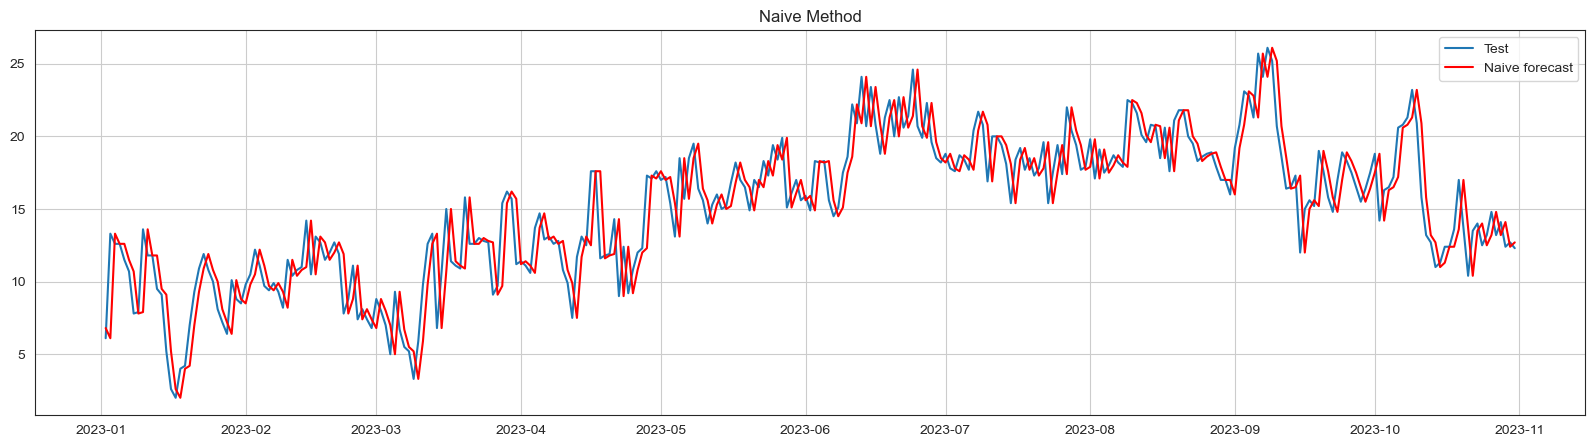

In [25]:
#Naive method forecast of the test dataset
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(naive_df['Naive_actual'], label='Test')
plt.plot(naive_df['Naive_pred'], label='Naive forecast',color='red')
plt.legend(loc='best')
plt.title('Naive Method')
plt.show()

In [26]:
#Evaluating the fit of the Naive method
maeNaive  = mean_absolute_error(naive_df['Naive_actual'],naive_df['Naive_pred'])
mseNaive  = (mean_squared_error(naive_df['Naive_actual'], naive_df['Naive_pred'])).round(2)
rmseNaive = np.sqrt(mean_squared_error(naive_df['Naive_actual'],naive_df['Naive_pred'])).round(2)
mapeNaive = np.round(np.mean(np.abs(naive_df['Naive_actual']-naive_df['Naive_pred'])/naive_df['Naive_actual'])*100,2)

results_naive = pd.DataFrame({'Method':['Naive method'],'MAE': [maeNaive],'MSE': [mseNaive] ,'MAPE': [mapeNaive], 'RMSE': [rmseNaive]})
results_naive = results_naive[['Method','MAE' ,'MSE','RMSE', 'MAPE']]
results_naive

,Method,MAE,MSE,RMSE,MAPE
0,Naive method,1.70132,4.9,2.21,13.21


#### Simple Moving Average

In [27]:
#creating a copy and calculate a rolling mean of 7 days simple moving average
SMATrain=train.copy()
SMATrain["SMAmaxtp"]=train["maxtp"].rolling(7).mean()

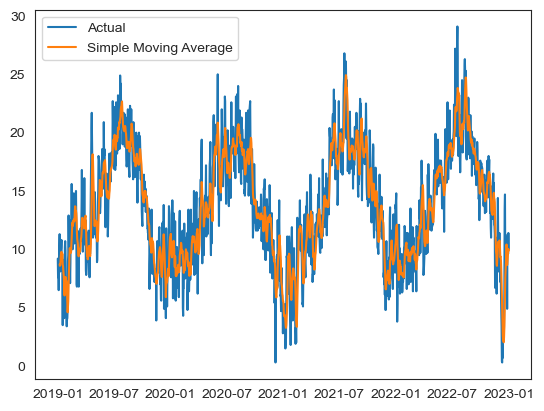

In [28]:
#plottting the 7 day SMA for the train dataset
plt.plot(train['date'],train['maxtp'],label="Actual")
plt.plot(SMATrain['date'],SMATrain['SMAmaxtp'],label="Simple Moving Average")
plt.legend()
plt.show()

In [29]:
#Calculating the 7 day SMA for the test dataset
SMAtest=test.copy()
SMAtest["SMAmaxtp"]=test["maxtp"].rolling(7).mean()

In [30]:
#reset the index 
SMAtest.reset_index(level=None, drop=True, inplace=False, col_level=0, col_fill='')
SMAtest.head(10)


,date,maxtp,SMAmaxtp
1461,2023-01-01,6.8,NaN
1462,2023-01-02,6.1,NaN
1463,2023-01-03,13.3,NaN
1464,2023-01-04,12.6,NaN
1465,2023-01-05,12.6,NaN
1466,2023-01-06,11.5,NaN
1467,2023-01-07,10.7,10.514286
1468,2023-01-08,7.8,10.657143
1469,2023-01-09,7.9,10.914286
1470,2023-01-10,13.6,10.957143


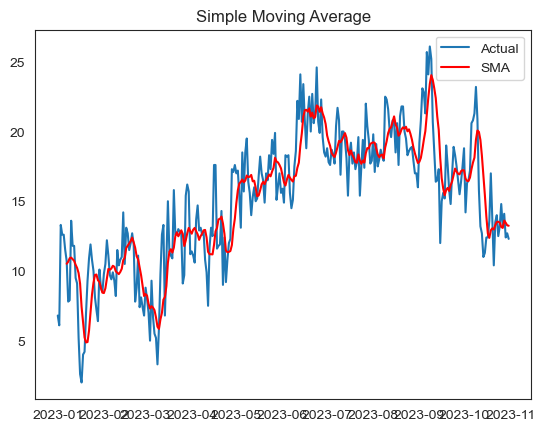

In [31]:
#plotting the smoothing curve for the 7 day SMA
plt.plot(test['date'],test['maxtp'],label="Actual")
plt.plot(SMAtest['date'],SMAtest['SMAmaxtp'],label="SMA",color='red')
plt.legend()
plt.title('Simple Moving Average')
plt.show()

In [32]:
#verifying the forecasted values
SMAtest=SMAtest.dropna(axis=0)
SMAtest

,date,maxtp,SMAmaxtp
1467,2023-01-07,10.7,10.514286
1468,2023-01-08,7.8,10.657143
1469,2023-01-09,7.9,10.914286
1470,2023-01-10,13.6,10.957143
1471,2023-01-11,11.8,10.842857
...,...,...,...
1760,2023-10-27,13.2,13.085714
1761,2023-10-28,14.1,13.614286
1762,2023-10-29,12.4,13.457143
1763,2023-10-30,12.7,13.271429


In [33]:
#Evaluating the fit of the Simple moving average method

sma_mae  = mean_absolute_error(SMAtest["maxtp"],SMAtest['SMAmaxtp'])
sma_mse  = (mean_squared_error(SMAtest['maxtp'], SMAtest['SMAmaxtp'])).round(2)
sma_rmse = np.sqrt(mean_squared_error(SMAtest['maxtp'], SMAtest['SMAmaxtp'])).round(2)
sma_mape = np.round(np.mean(np.abs(SMAtest['maxtp']-SMAtest['SMAmaxtp'])/SMAtest['maxtp'])*100,2)


results_sma = pd.DataFrame({'Method':['SMA method'],'MAE': [sma_mae],'MSE': [sma_mse] ,'MAPE': [sma_mape], 'RMSE': [sma_rmse]})
results_sma = results_sma[['Method','MAE' ,'MSE','RMSE', 'MAPE']]
results_sma

,Method,MAE,MSE,RMSE,MAPE
0,SMA method,1.693432,4.96,2.23,14.34


#### Weighted Moving Average

In [34]:
#creating a copy for calculating the Weighted moving average
WMAtest=test.copy()


In [35]:
#hard coding the weights to be added to the past data based on the significance
weights=np.array([0.0078125,0.015625,0.03125,0.0625,0.125,0.25,0.5])
WMAtest["WMAmaxtp"]=WMAtest["maxtp"].rolling(len(weights)).\
    apply(lambda x: np.sum(weights*x))

In [36]:
#verifying the top 10 records in the dataframe
WMAtest.head(10)

,date,maxtp,WMAmaxtp
1461,2023-01-01,6.8,NaN
1462,2023-01-02,6.1,NaN
1463,2023-01-03,13.3,NaN
1464,2023-01-04,12.6,NaN
1465,2023-01-05,12.6,NaN
1466,2023-01-06,11.5,NaN
1467,2023-01-07,10.7,11.151563
1468,2023-01-08,7.8,9.449219
1469,2023-01-09,7.9,8.650781
1470,2023-01-10,13.6,11.073438


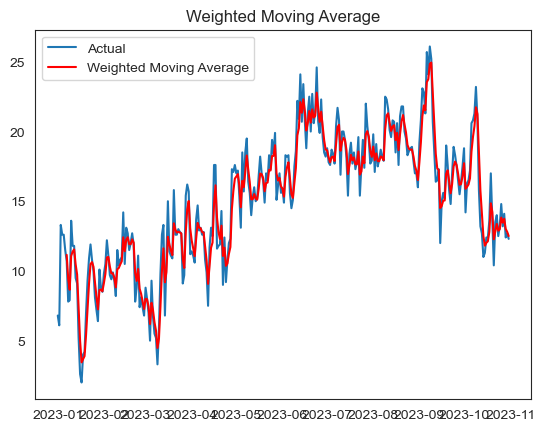

In [37]:
#plotting the WMA forecast based on the weights
plt.plot(test['date'],test['maxtp'],label="Actual")
plt.plot(WMAtest['date'],WMAtest['WMAmaxtp'],label="Weighted Moving Average", color='red')
plt.legend()
plt.title('Weighted Moving Average')
plt.show()

In [38]:
#removing the na records from the dataset
WMAtest = WMAtest[:len(WMAtest)].dropna()
WMAtest

,date,maxtp,WMAmaxtp
1467,2023-01-07,10.7,11.151563
1468,2023-01-08,7.8,9.449219
1469,2023-01-09,7.9,8.650781
1470,2023-01-10,13.6,11.073438
1471,2023-01-11,11.8,11.387500
...,...,...,...
1760,2023-10-27,13.2,13.460938
1761,2023-10-28,14.1,13.739844
1762,2023-10-29,12.4,13.017187
1763,2023-10-30,12.7,12.803906


In [39]:
#Evaluating the fit of the weighted moving average method

wma_mae  = mean_absolute_error(WMAtest["maxtp"],WMAtest['WMAmaxtp'])
wma_mse  = (mean_squared_error(WMAtest['maxtp'], WMAtest['WMAmaxtp'])).round(2)
wma_rmse = np.sqrt(mean_squared_error(WMAtest['maxtp'], WMAtest['WMAmaxtp'])).round(2)
wma_mape = np.round(np.mean(np.abs(WMAtest['maxtp']-WMAtest['WMAmaxtp'])/test['maxtp'])*100,2)


results_wma = pd.DataFrame({'Method':['WMA method'],'MAE': [wma_mae],'MSE': [wma_mse] ,'MAPE': [wma_mape], 'RMSE': [wma_rmse]})
results_wma = results_wma[['Method','MAE' ,'MSE','RMSE', 'MAPE']]
results_wma

,Method,MAE,MSE,RMSE,MAPE
0,WMA method,0.857023,1.19,1.09,6.88


### Analysis

In [40]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA


In [41]:
#method to decompose the data to find the additive or multiplicative nature of the time series
def decompose(df, column_name):
    result_mul = seasonal_decompose(df[column_name], model='multiplicative', extrapolate_trend = 0)
    result_add = seasonal_decompose(df[column_name], model = 'additive', extrapolate_trend=0)

    plt.rcParams.update({'figure.figsize': (20, 10)})
    result_mul.plot().suptitle('Multiplicative Decompose', fontsize=30)
    result_add.plot().suptitle('Additive Decompose', fontsize=30)
    plt.show()
    
    return result_mul, result_add


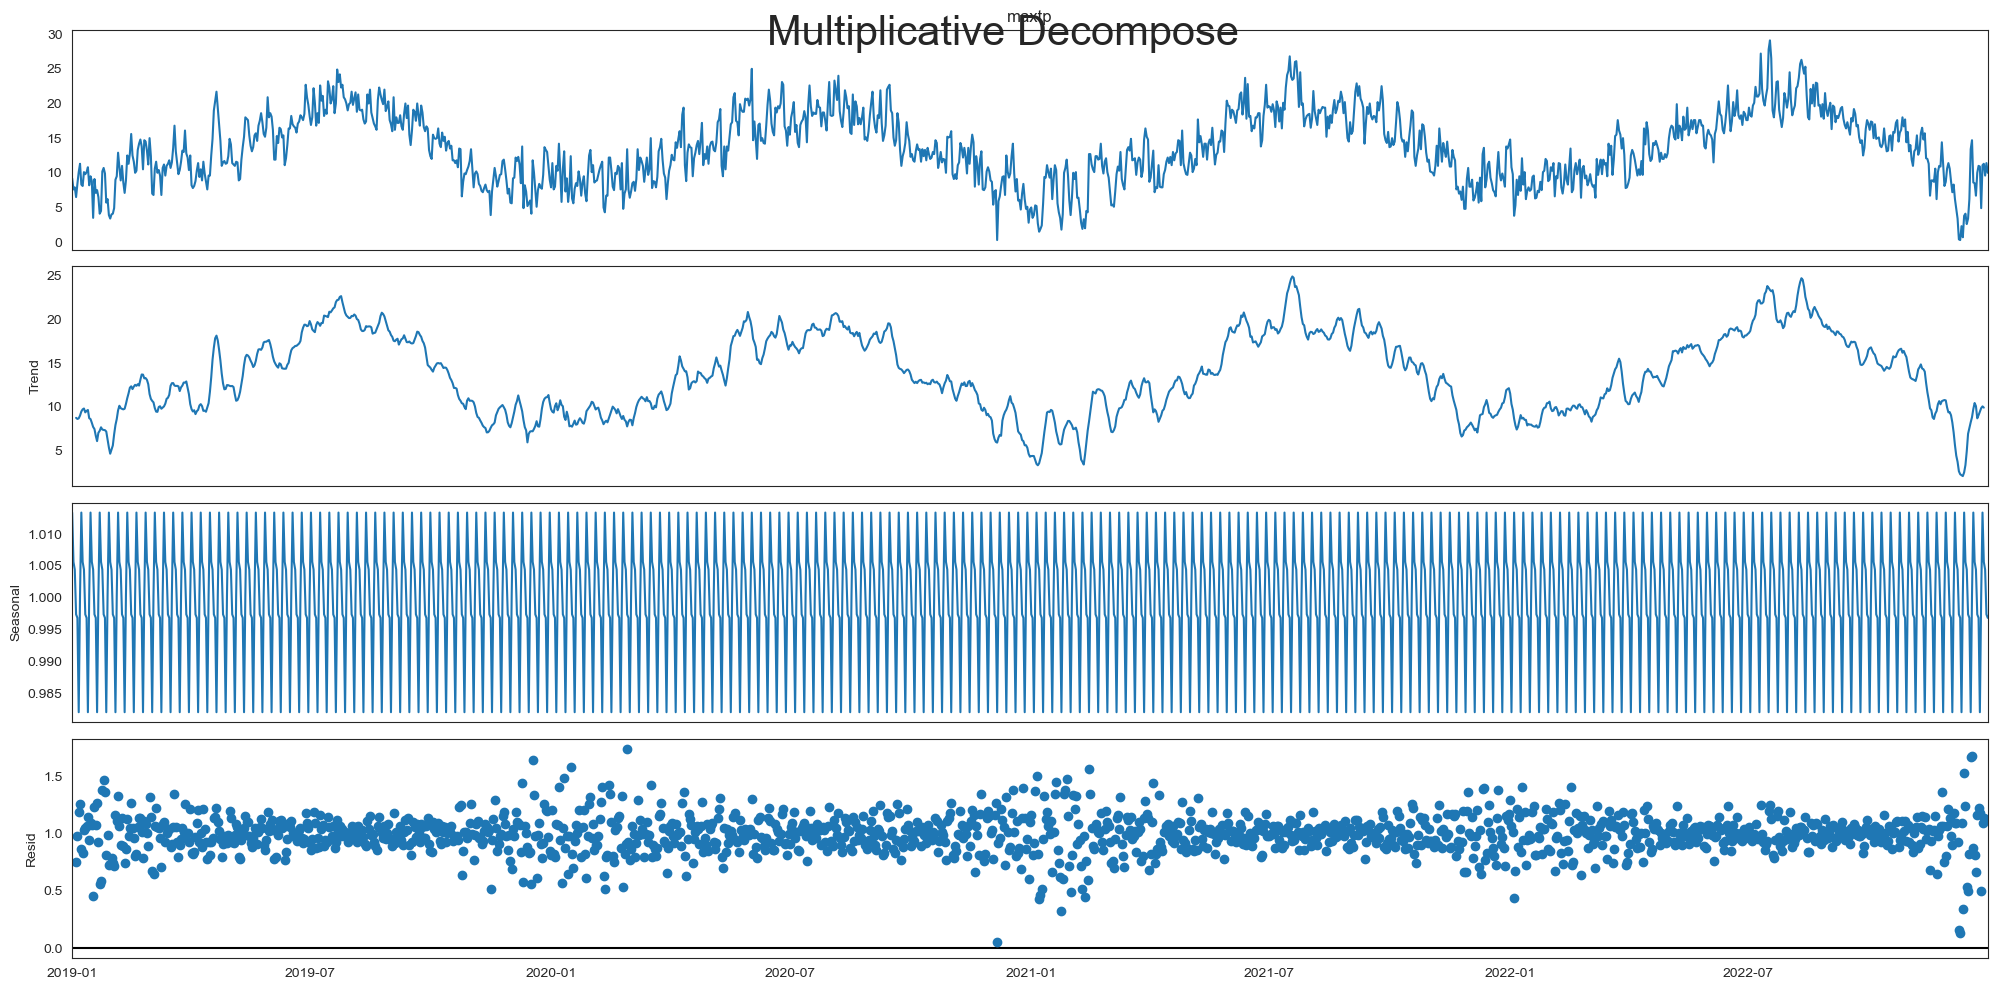

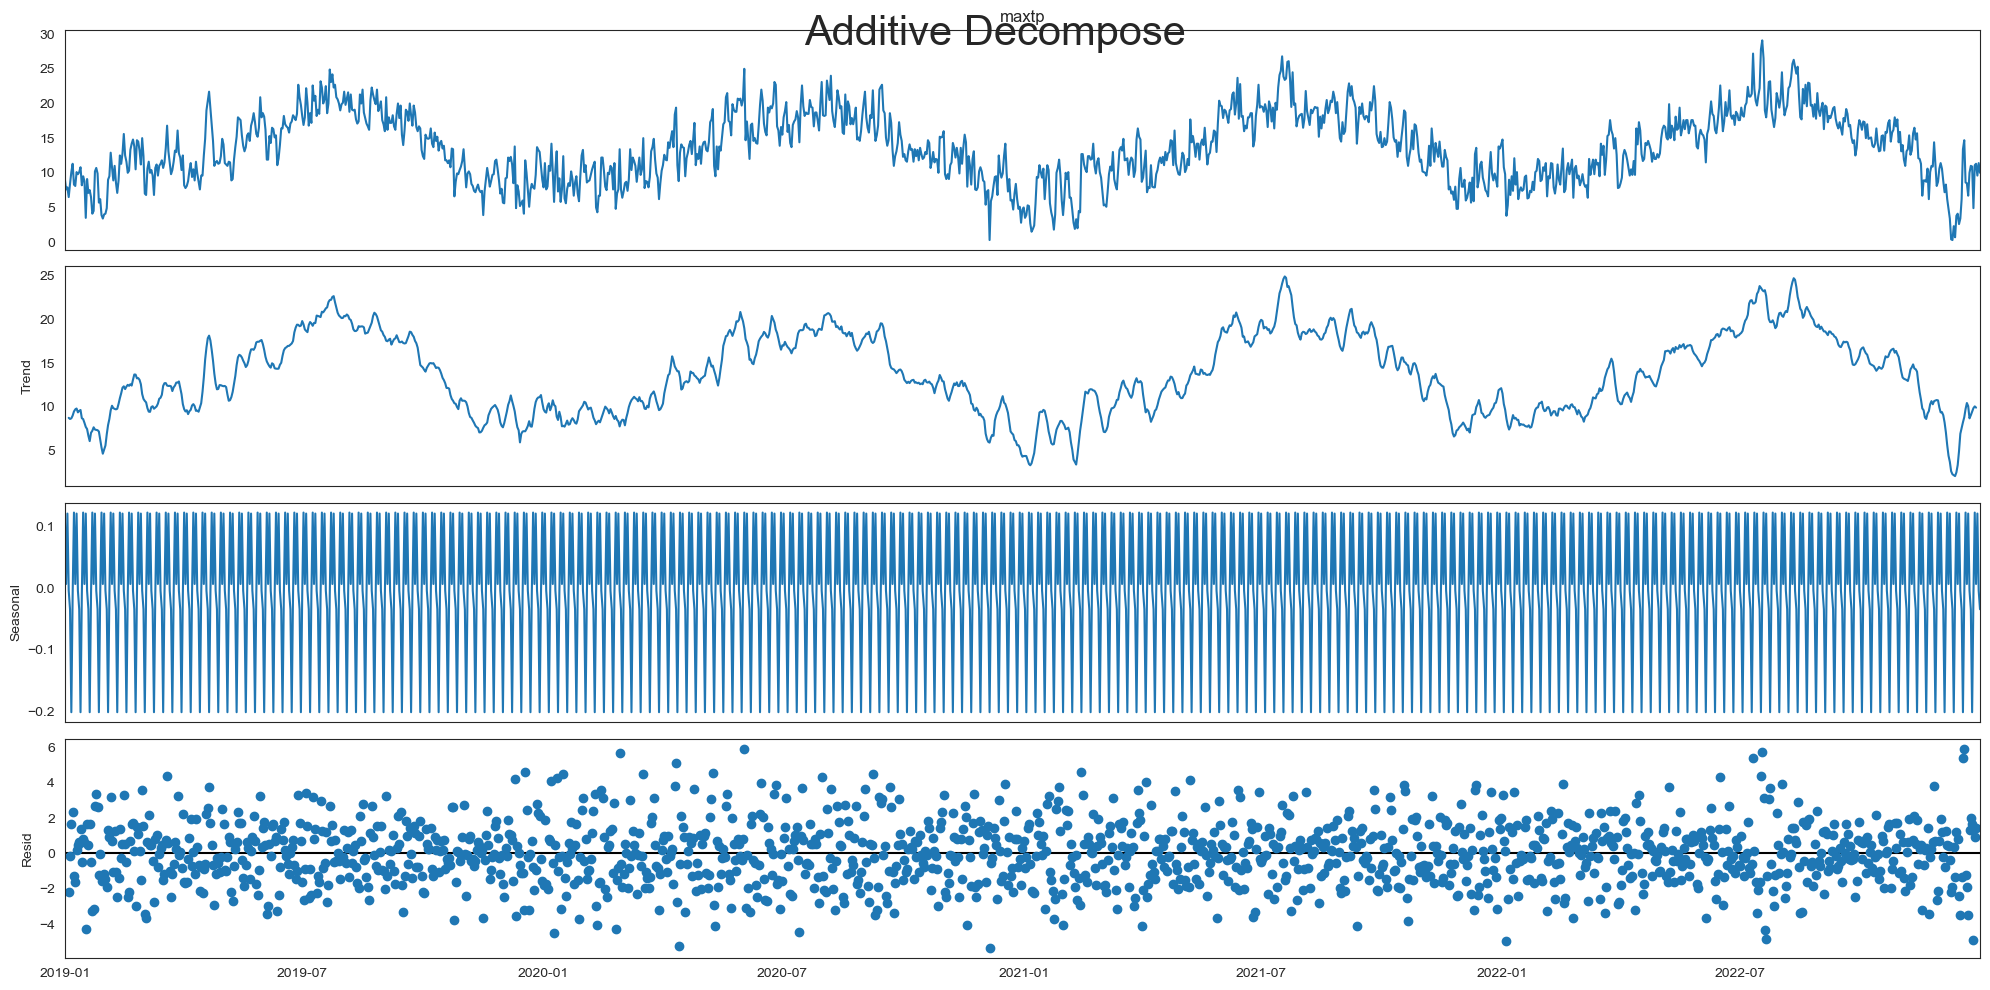

In [42]:
#invoking the method to print the additive and multiplicative decomposition
season_analysis=train.copy()
season_analysis.set_index('date', inplace=True)
result_mul, result_add = decompose(season_analysis, 'maxtp')

In [43]:
#check for stationarity of the data using ADF test

dftest = adfuller(season_analysis['maxtp'], autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

1. ADF :  -2.6638240648080327
2. P-Value :  0.08051019281161897
3. Num Of Lags :  17
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 1443
5. Critical Values :
	 1% :  -3.434889827343955
	 5% :  -2.863545026607168
	 10% :  -2.5678374612882515


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

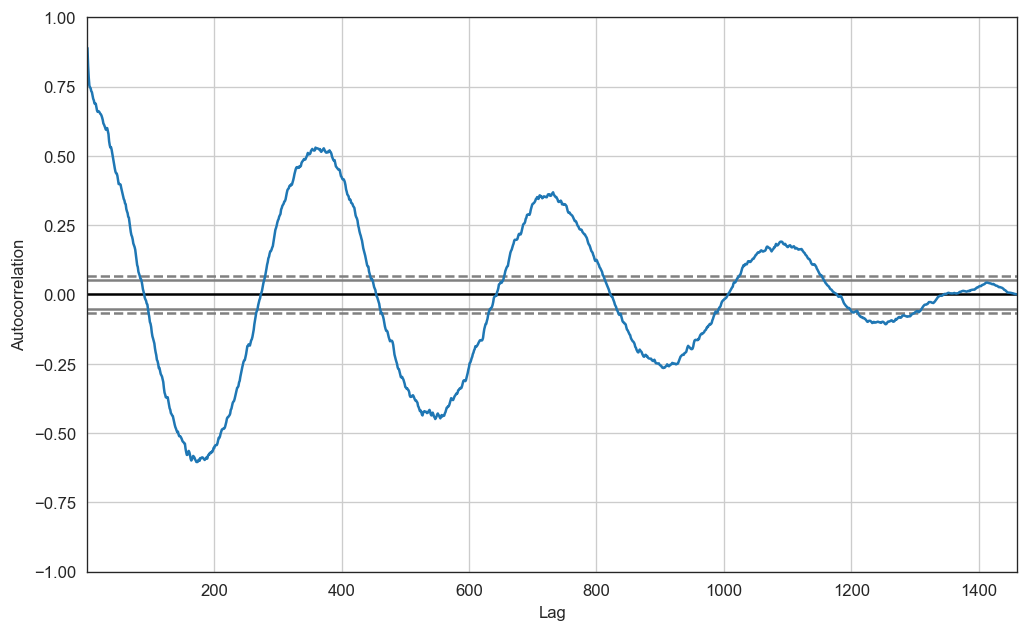

In [44]:
#draw autocorrelation plot for the temperature 
# Draw Plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(season_analysis["maxtp"].tolist())

In [45]:
#KPSS test for checkign stationarity of the data
from statsmodels.tsa.stattools import kpss
kpsstest = kpss(train['maxtp'], regression='ct')
kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
for key,value in kpsstest[3].items():
    kpss_output['Critical Value (%s)'%key] = value
print (kpss_output)

Test Statistic            0.096431
p-value                   0.100000
Lags Used                24.000000
Critical Value (10%)      0.119000
Critical Value (5%)       0.146000
Critical Value (2.5%)     0.176000
Critical Value (1%)       0.216000
dtype: float64


C:\Users\jackb\AppData\Local\Temp\ipykernel_37940\1379766281.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(train['maxtp'], regression='ct')


In [46]:
#calculating the first difference in the temperature data 
first_difference=train.copy()
first_difference['maxtp']=(train['maxtp']- train['maxtp'].shift(1))
first_difference=first_difference.dropna(inplace=False)

<Axes: >

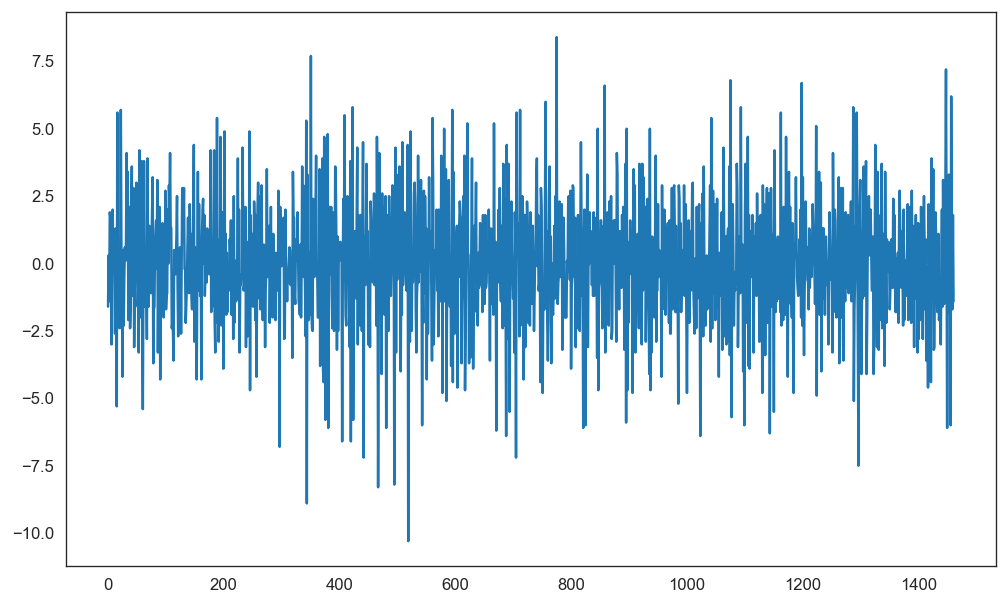

In [47]:
#plotting the first difference for verifying constant mean
first_difference['maxtp'].plot()

In [48]:
#recheck for checking the probability statistic
dftest = adfuller(first_difference['maxtp'], autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

1. ADF :  -13.326104954494696
2. P-Value :  6.31692388148384e-25
3. Num Of Lags :  16
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 1443
5. Critical Values :
	 1% :  -3.434889827343955
	 5% :  -2.863545026607168
	 10% :  -2.5678374612882515


### Exponential smoothing

#### Simple Exponential Smoothing

In [49]:
from statsmodels.tsa.api import SimpleExpSmoothing, Holt

In [50]:
#copying the train and test data for analysis
simplees=train.copy()
simpleestest=test.copy()
simplees=simplees.set_index('date',inplace=False)
simpleestest=simpleestest.set_index('date',inplace=False)


In [51]:
#invoking simple exponential smoothing for only level component
fit_ses= SimpleExpSmoothing(simplees["maxtp"]).fit(smoothing_level=0.3,optimized=False)

C:\Users\jackb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [52]:
#printing the summary of the fit
print(fit_ses.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                  maxtp   No. Observations:                 1461
Model:             SimpleExpSmoothing   SSE                           7990.943
Optimized:                      False   AIC                           2486.513
Trend:                           None   BIC                           2497.087
Seasonal:                        None   AICC                          2486.541
Seasonal Periods:                None   Date:                 Wed, 03 Jan 2024
Box-Cox:                        False   Time:                         22:11:03
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.3000000                alpha                False
initial_level              9.2000000                

In [53]:
#printing the predicted/forecasted temeprature for Simple smoothing
prediction_ses= fit_ses.forecast(len(test))
print(prediction_ses)

2023-01-01    10.175432
2023-01-02    10.175432
2023-01-03    10.175432
2023-01-04    10.175432
2023-01-05    10.175432
                ...    
2023-10-27    10.175432
2023-10-28    10.175432
2023-10-29    10.175432
2023-10-30    10.175432
2023-10-31    10.175432
Freq: D, Length: 304, dtype: float64


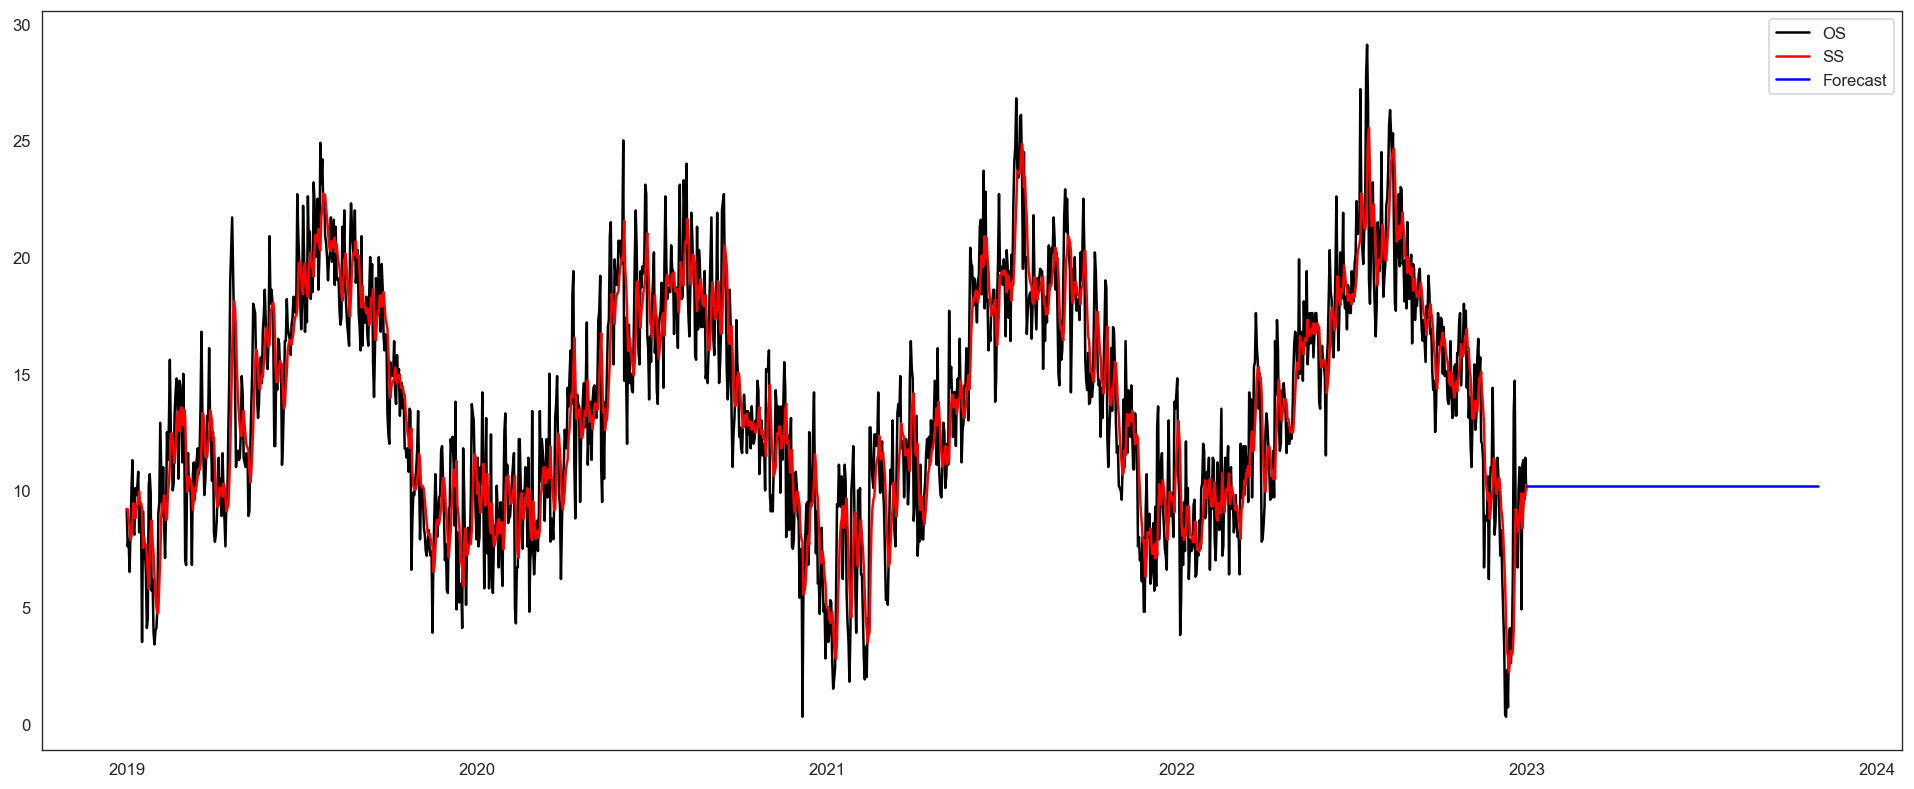

In [54]:
#plot the forecast vvalue for the simple exponential smoothing
plt.figure(figsize=(20,8))
plt.plot(simplees['maxtp'], color="black", label="OS")
plt.plot(fit_ses.fittedvalues,color="red", label="SS")
plt.plot(prediction_ses, color="blue", label="Forecast")
plt.legend()

In [55]:
#calculating the fitness of the model of train
mae_ses=mean_absolute_error(train['maxtp'],fit_ses.fittedvalues)
rmse_ses= mean_squared_error(train['maxtp'],fit_ses.fittedvalues)**0.5
mape_ses=mean_absolute_percentage_error(train['maxtp'],fit_ses.fittedvalues)
print("ses_mae: {:.3f},rmse:{:.3f},mape:{:.3f}".format(mae_ses,rmse_ses,mape_ses))

ses_mae: 1.840,rmse:2.339,mape:0.204


In [56]:
#calculating the fitness of the model of the test data
mae_ses=mean_absolute_error(test['maxtp'],prediction_ses)
rmse_ses= mean_squared_error(test['maxtp'],prediction_ses)**0.5
mape_ses=mean_absolute_percentage_error(test['maxtp'],prediction_ses)
print("ses_mae: {:.3f},rmse:{:.3f},mape:{:.3f}".format(mae_ses,rmse_ses,mape_ses))

ses_mae: 5.723,rmse:6.807,mape:0.380


In [57]:
#Double exponential smoothing model
fit_holt=Holt(simplees["maxtp"]).fit()
print(fit_holt.summary())

                              Holt Model Results                              
Dep. Variable:                  maxtp   No. Observations:                 1461
Model:                           Holt   SSE                           7638.772
Optimized:                       True   AIC                           2424.663
Trend:                       Additive   BIC                           2445.811
Seasonal:                        None   AICC                          2424.721
Seasonal Periods:                None   Date:                 Wed, 03 Jan 2024
Box-Cox:                        False   Time:                         22:11:03
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.7075607                alpha                 True
smoothing_trend            0.0201600                

C:\Users\jackb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [58]:
#printing the double exponential smoothing forecasted values
predictions_holt=fit_holt.forecast(len(test))
print(predictions_holt)

2023-01-01    10.262186
2023-01-02    10.242248
2023-01-03    10.222310
2023-01-04    10.202371
2023-01-05    10.182433
                ...    
2023-10-27     4.300663
2023-10-28     4.280725
2023-10-29     4.260786
2023-10-30     4.240848
2023-10-31     4.220910
Freq: D, Length: 304, dtype: float64


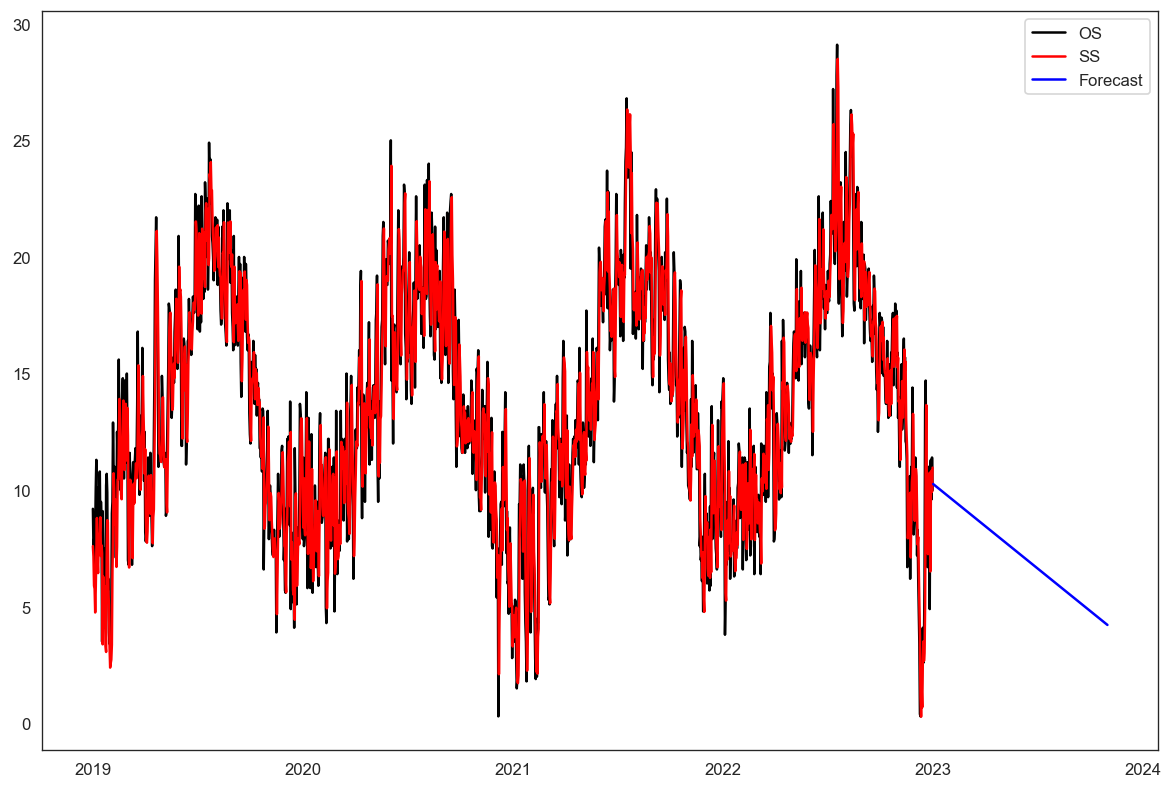

In [59]:
#plotting the forecasted values of the double exponential smoothing
plt.figure(figsize=(12,8))
plt.plot(simplees['maxtp'], color="black", label="OS")
plt.plot(fit_holt.fittedvalues,color="red", label="SS")
plt.plot(predictions_holt, color="blue", label="Forecast")
plt.legend()

In [60]:
#Evaluating the goodness of the model
mae_holt=mean_absolute_error(test['maxtp'],predictions_holt)
rmse_holt= mean_squared_error(test['maxtp'],predictions_holt)**0.5
mape_holt=mean_absolute_percentage_error(test['maxtp'],predictions_holt)
print("ses_mae: {:.3f},rmse:{:.3f},mape:{:.3f}".format(mae_ses,rmse_ses,mape_ses))

ses_mae: 5.723,rmse:6.807,mape:0.380


In [61]:
#Invoking the exponential smoothing method to perform triple exponential smooting
fit_tes=ExponentialSmoothing(simplees["maxtp"],trend="add", seasonal="add", seasonal_periods=365).fit()
print(fit_tes.summary())

C:\Users\jackb\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                    maxtp   No. Observations:                 1461
Model:             ExponentialSmoothing   SSE                           5548.707
Optimized:                         True   AIC                           2687.622
Trend:                         Additive   BIC                           4638.480
Seasonal:                      Additive   AICC                          2941.088
Seasonal Periods:                   365   Date:                 Wed, 03 Jan 2024
Box-Cox:                          False   Time:                         22:11:05
Box-Cox Coeff.:                    None                                         
                           coeff                 code              optimized      
----------------------------------------------------------------------------------
smoothing_level                0.6396552                alpha                 True
smoothing_trend       

In [62]:
#printing the predicted values of the model
prediction_tes=fit_tes.forecast(len(test))
prediction_tes

2023-01-01    11.099872
2023-01-02     8.848434
2023-01-03     8.446930
2023-01-04     8.520527
2023-01-05     9.118447
                ...    
2023-10-27    15.579020
2023-10-28    14.529153
2023-10-29    15.629401
2023-10-30    14.653842
2023-10-31    15.553563
Freq: D, Length: 304, dtype: float64

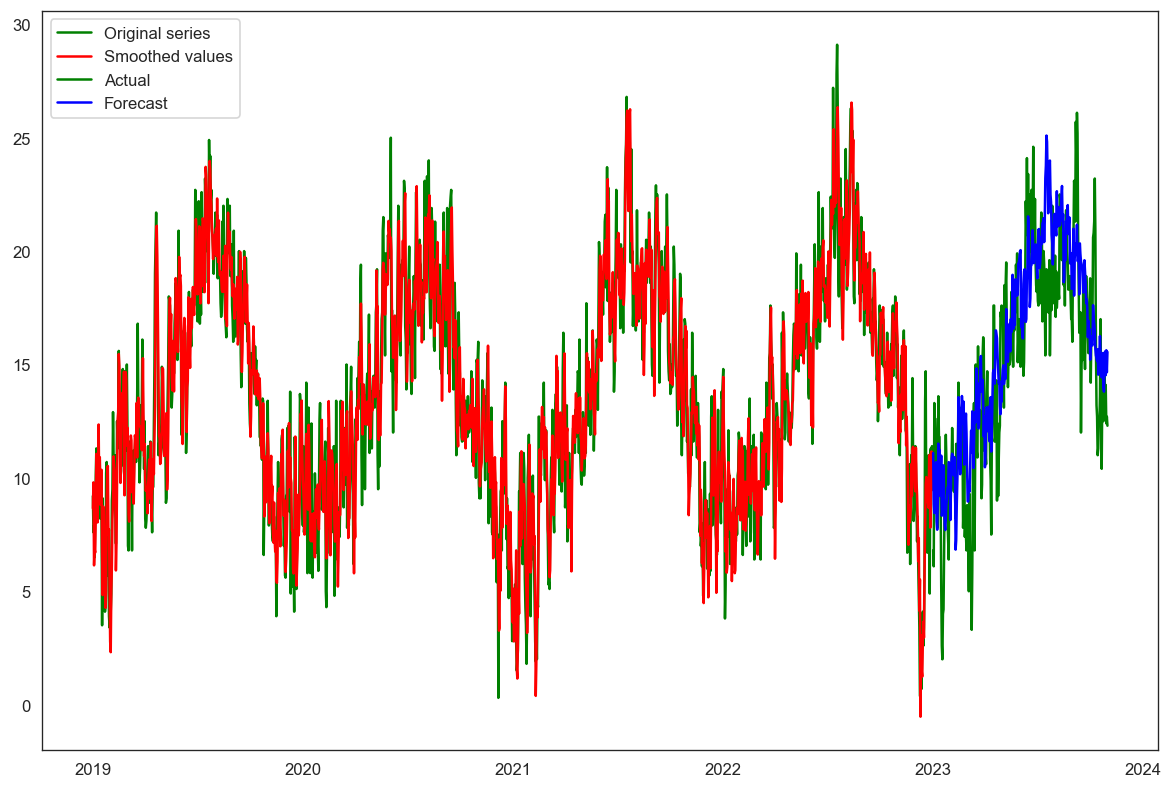

In [63]:
#plotting the forecasted values to the actual values
plt.figure(figsize=(12,8))
plt.plot(simplees['maxtp'], color="green", label="Original series")
plt.plot(fit_tes.fittedvalues,color="red", label="Smoothed values")
plt.plot(simpleestest['maxtp'], color="green", label="Actual")
plt.plot(prediction_tes, color="blue", label="Forecast")

plt.legend()

In [64]:
#Evaluating the forecast of the triple exponential smoothing
tes_mae  = mean_absolute_error(simpleestest["maxtp"],prediction_tes)
tes_mse  = (mean_squared_error(simpleestest['maxtp'], prediction_tes)).round(2)
tes_rmse = np.sqrt(mean_squared_error(simpleestest['maxtp'], prediction_tes)).round(2)
tes_mape = np.round(np.mean(np.abs(simpleestest['maxtp']-prediction_tes)/simpleestest['maxtp'])*100,2)

results_tes = pd.DataFrame({'Method':['Holt Winter method'],'MAE': [tes_mae],'MSE': [tes_mse] ,'MAPE': [tes_mape], 'RMSE': [tes_rmse]})
results_tes = results_tes[['Method','MAE' ,'MSE','RMSE', 'MAPE']]
results_tes

,Method,MAE,MSE,RMSE,MAPE
0,Holt Winter method,2.424297,9.19,3.03,21.45



### Arima model

In [65]:
#check stationarity
adfuller(train['maxtp'])

(-2.6638240648080327,
 0.08051019281161897,
 17,
 1443,
 {'1%': -3.434889827343955,
  '5%': -2.863545026607168,
  '10%': -2.5678374612882515},
 6288.081834749524)

In [66]:
#calculate the first difference of the temeprature data
first_difference=(train['maxtp']-train['maxtp'].shift(1)).dropna()

<Axes: >

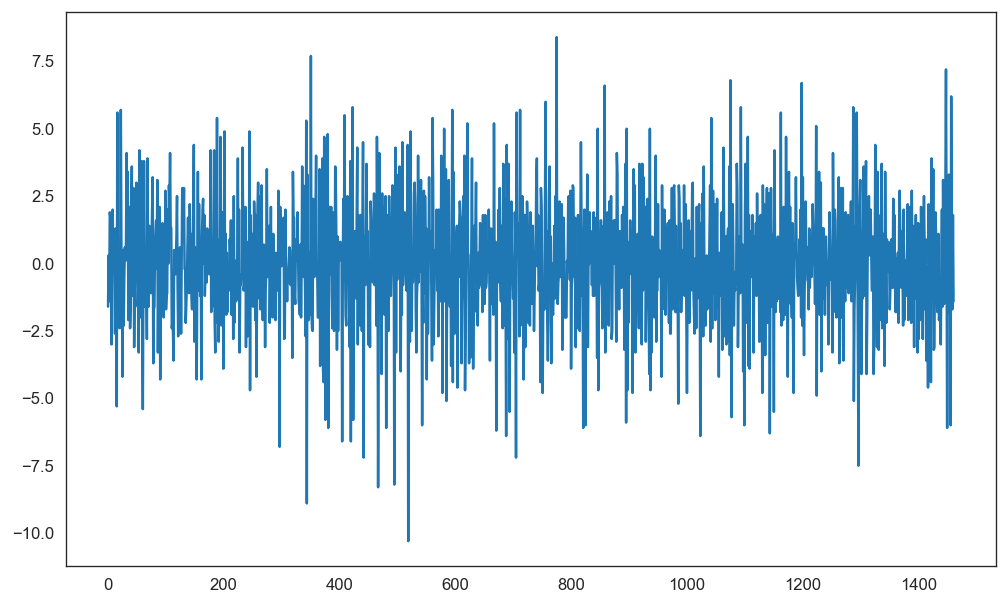

In [67]:
#plotting the curve
first_difference.plot()

In [68]:
round(adfuller(first_difference)[1],3)

0.0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


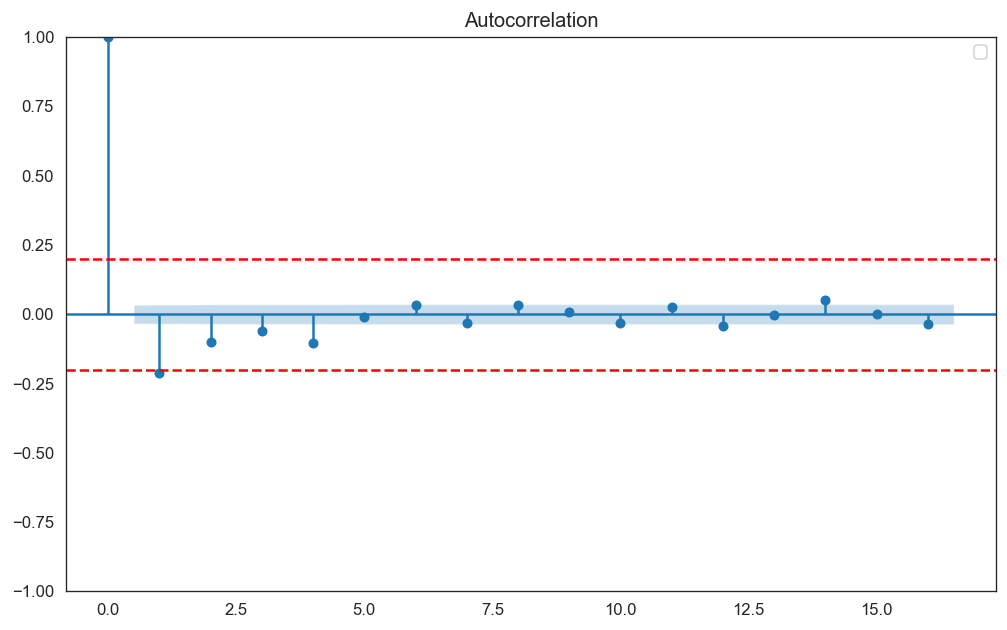

In [69]:
#plotting the autocorrelation fucntion plot(ACF)
fig, ax = plt.subplots()
plot_acf(first_difference, lags=16, alpha=0.2, ax=ax)
ax.axhline(y=0.2, linestyle='--', color='red')  
ax.axhline(y=-0.2, linestyle='--', color='red') 
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


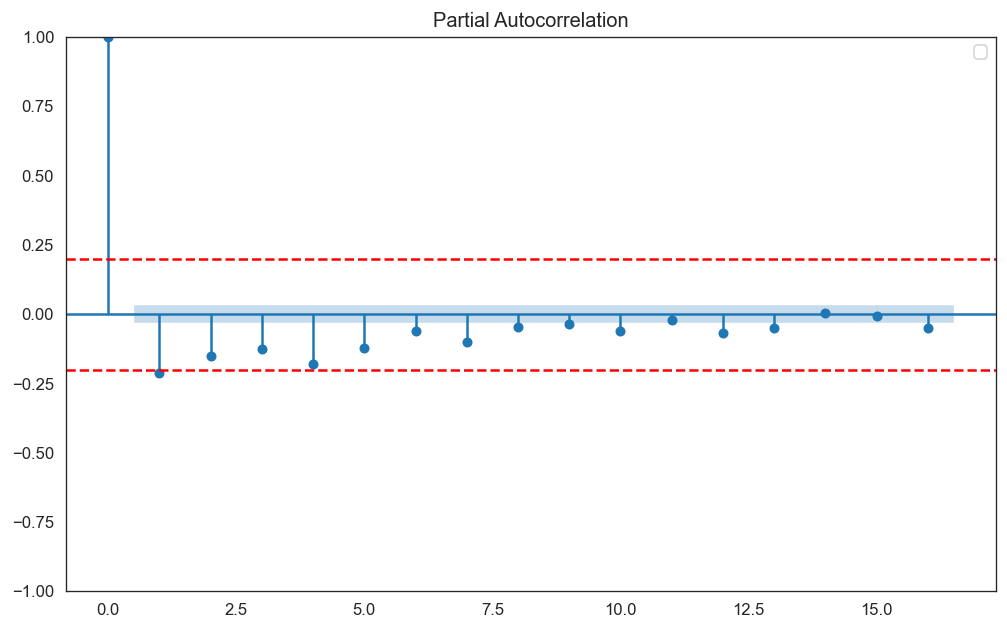

In [70]:
#plotting the partial autocorrelation fucntion plot(PACF)

fig, ax = plt.subplots()
plot_pacf(first_difference, lags=16, alpha=0.2, ax=ax)
ax.axhline(y=0.2, linestyle='--', color='red')  
ax.axhline(y=-0.2, linestyle='--', color='red') 
plt.legend()
plt.show()

In [71]:
#lags calculated from the ACF and PACF ARIMA 111 is plotted
model111=ARIMA(train['maxtp'],order=(1,1,1))
fit111=model111.fit()
print(fit111.summary())

                               SARIMAX Results                                
Dep. Variable:                  maxtp   No. Observations:                 1461
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3189.177
Date:                Wed, 03 Jan 2024   AIC                           6384.353
Time:                        22:11:06   BIC                           6400.212
Sample:                             0   HQIC                          6390.269
                               - 1461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5505      0.030     18.169      0.000       0.491       0.610
ma.L1         -0.8935      0.016    -55.041      0.000      -0.925      -0.862
sigma2         4.6202      0.154     29.998      0.0

<Axes: >

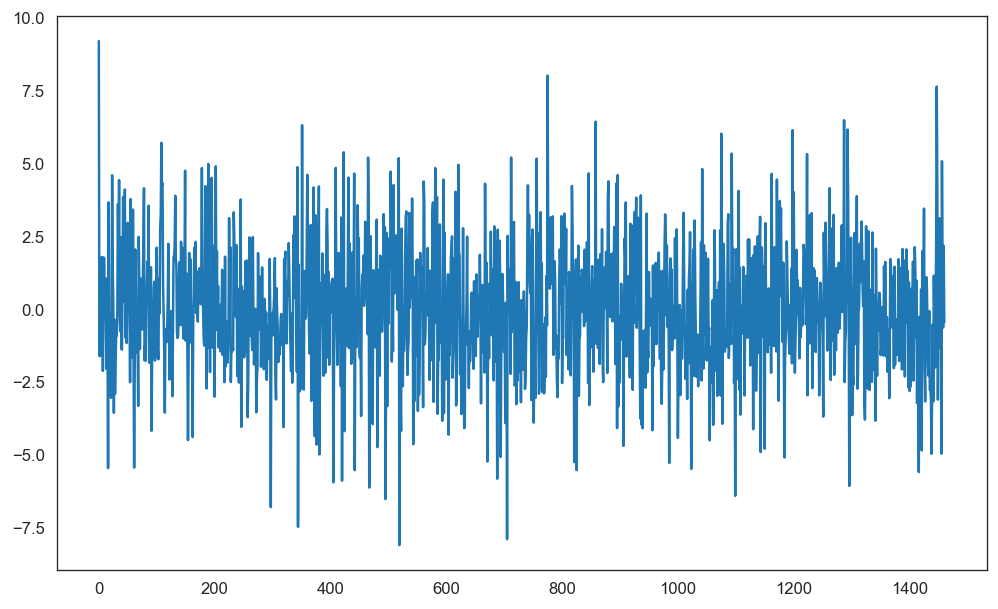

In [72]:
#rediduals plotted 
fit111.resid.plot()

In [73]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(fit111.resid,lags=10)

,lb_stat,lb_pvalue
1,0.000181,0.989262
2,0.220601,0.895565
3,0.267936,0.965942
4,5.631850,0.228381
5,5.691817,0.337370
6,8.017840,0.236799
7,8.438329,0.295532
8,9.939068,0.269329
9,10.152081,0.338314
10,11.086517,0.350817


In [74]:
#forecasting from ARIMA 111
prediction111= fit111.forecast(len(test))


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


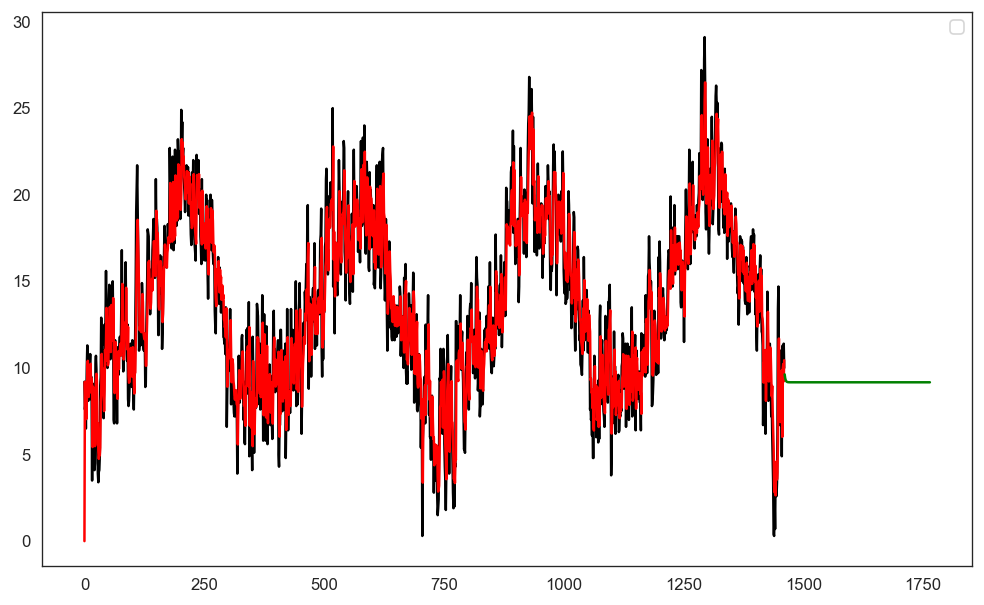

In [75]:
#plotting the forecasted value 
plt.plot(train['maxtp'],color='black')
plt.plot(fit111.fittedvalues, color='red')
plt.plot(prediction111, color='green')
plt.legend()

In [76]:
#evaluating the model performance
arima_mae  = mean_absolute_error(simpleestest["maxtp"],prediction111)
arima_mse  = (mean_squared_error(simpleestest['maxtp'], prediction111)).round(2)
arima_rmse = np.sqrt(mean_squared_error(simpleestest['maxtp'], prediction111)).round(2)
arima_mape = np.round(np.mean(np.abs(simpleestest['maxtp']-prediction111)/simpleestest['maxtp'])*100,2)


results_arima = pd.DataFrame({'Method':['ARIMA'],'MAE': [arima_mae],'MSE': [arima_mse] ,'MAPE': [arima_mape], 'RMSE': [arima_rmse]})
results_arima = results_arima[['Method','MAE' ,'MSE','RMSE', 'MAPE']]
results_arima

,Method,MAE,MSE,RMSE,MAPE
0,ARIMA,6.441415,57.13,7.56,NaN


In [77]:
#ARIMA 211 is fitted

model211=ARIMA(train['maxtp'],order=(2,1,1))
fit211=model211.fit()
print(fit211.summary())

                               SARIMAX Results                                
Dep. Variable:                  maxtp   No. Observations:                 1461
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -3189.165
Date:                Wed, 03 Jan 2024   AIC                           6386.331
Time:                        22:11:07   BIC                           6407.475
Sample:                             0   HQIC                          6394.218
                               - 1461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5516      0.031     18.004      0.000       0.492       0.612
ar.L2         -0.0043      0.029     -0.146      0.884      -0.062       0.053
ma.L1         -0.8925      0.018    -49.487      0.0

In [78]:
#ARIMA 311 is fitted

model311=ARIMA(train['maxtp'],order=(3,1,1))
fit311=model311.fit()
print(fit311.summary())

                               SARIMAX Results                                
Dep. Variable:                  maxtp   No. Observations:                 1461
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -3188.463
Date:                Wed, 03 Jan 2024   AIC                           6386.927
Time:                        22:11:07   BIC                           6413.358
Sample:                             0   HQIC                          6396.787
                               - 1461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5423      0.033     16.518      0.000       0.478       0.607
ar.L2          0.0083      0.031      0.270      0.787      -0.052       0.069
ar.L3         -0.0339      0.031     -1.109      0.2

In [79]:
#ARIMA 112 is fitted

model112=ARIMA(train['maxtp'],order=(1,1,2))
fit112=model112.fit()
print(fit112.summary())

                               SARIMAX Results                                
Dep. Variable:                  maxtp   No. Observations:                 1461
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -3189.167
Date:                Wed, 03 Jan 2024   AIC                           6386.333
Time:                        22:11:07   BIC                           6407.478
Sample:                             0   HQIC                          6394.221
                               - 1461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5445      0.058      9.449      0.000       0.432       0.657
ma.L1         -0.8857      0.063    -14.027      0.000      -1.009      -0.762
ma.L2         -0.0062      0.048     -0.131      0.8

In [80]:
#ARIMA 113 is fitted

model113=ARIMA(train['maxtp'],order=(1,1,3))
fit113=model113.fit()
print(fit113.summary())

                               SARIMAX Results                                
Dep. Variable:                  maxtp   No. Observations:                 1461
Model:                 ARIMA(1, 1, 3)   Log Likelihood               -3188.535
Date:                Wed, 03 Jan 2024   AIC                           6387.071
Time:                        22:11:07   BIC                           6413.502
Sample:                             0   HQIC                          6396.931
                               - 1461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4668      0.112      4.158      0.000       0.247       0.687
ma.L1         -0.8104      0.114     -7.114      0.000      -1.034      -0.587
ma.L2         -0.0127      0.051     -0.247      0.8

In [81]:
from pmdarima.arima import auto_arima

In [82]:
#cross verifying using autoarima function to validate the pdq components in the model
auto_arima(train['maxtp'])

ARIMA(order=(1, 1, 1), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [83]:
auto_arima(first_difference)

ARIMA(order=(1, 0, 1), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

#### SARIMA

In [84]:
# Shift the current temperature to the next day. 
predicted_df = main_weather["maxtp"].to_frame().shift(1).rename(columns = {"maxtp": "T_mu_pred" })
actual_df = main_weather["maxtp"].to_frame().rename(columns = {"maxtp": "T_mu_actual" })

# Concatenate the actual and predicted temperature
one_step_df = pd.concat([main_weather['date'],actual_df,predicted_df],axis=1)

# Select from the second row, because there is no prediction for today due to shifting.
one_step_df = one_step_df[1:]
one_step_df=one_step_df.set_index('date',inplace=False)
one_step_df

,T_mu_actual,T_mu_pred
date,,
2019-01-02,7.6,9.2
2019-01-03,7.9,7.6
2019-01-04,6.5,7.9
2019-01-05,8.4,6.5
2019-01-06,10.1,8.4
...,...,...
2023-10-27,13.2,14.8
2023-10-28,14.1,13.2
2023-10-29,12.4,14.1


In [85]:
import itertools
import warnings
warnings.filterwarnings('ignore')
# Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0, 2)

# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, q and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [93]:
#iterating and invoking the sarimax function to find the model with least AIC
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(one_step_df.T_mu_actual,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)

            results = mod.fit()

            print('SARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
        except:
            continue

SARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:14500.319216379456
SARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:12778.527540021614
SARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:9712.818642567829
SARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:9269.271933450094
SARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:9691.470608342986
SARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:9329.039748239242
SARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:9280.447240117863
SARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:9243.706423061016
SARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:12464.286118856393
SARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:11172.845111767914
SARIMA(0, 0, 1)x(0, 1, 0, 12)12 - AIC:9074.135278797105
SARIMA(0, 0, 1)x(0, 1, 1, 12)12 - AIC:8510.888749944159
SARIMA(0, 0, 1)x(1, 0, 0, 12)12 - AIC:9039.11039940322
SARIMA(0, 0, 1)x(1, 0, 1, 12)12 - AIC:8570.839707173778
SARIMA(0, 0, 1)x(1, 1, 0, 12)12 - AIC:8596.998076728167
SARIMA(0, 0, 1)x(1, 1, 1, 12)12 - AIC:8496.82910455028
SARIMA(0, 1, 0)x(0, 0, 0, 12)12 - AIC:7948.516397317706
SARIMA(0, 1, 0)x(0, 0, 1, 12)12 - AIC:7900.861

In [87]:
# Import the statsmodels library for using SARIMAX model
import statsmodels.api as sm

# Fit the SARIMAX model using optimal parameters
mod = sm.tsa.statespace.SARIMAX(one_step_df.T_mu_actual,
                                order=(1, 1, 1),
                                seasonal_order=(0, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit()

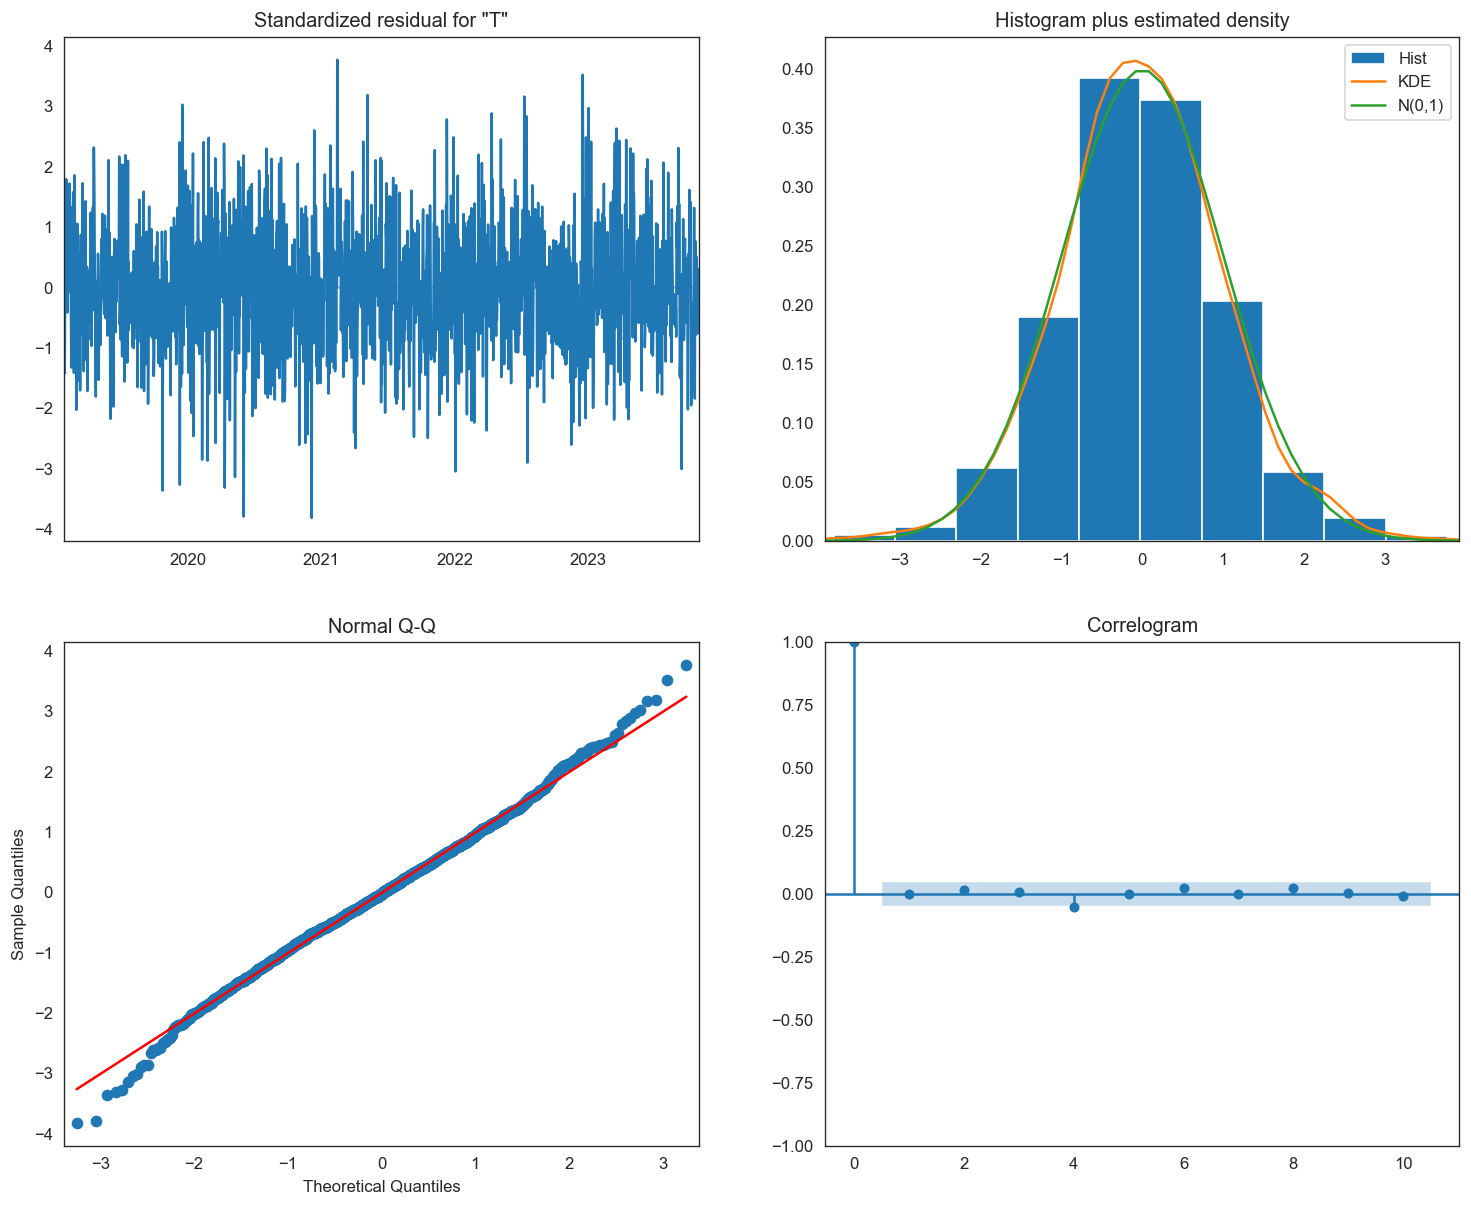

In [88]:
results.plot_diagnostics(figsize=(15, 12))
plt.show()

In [89]:
from statsmodels.tsa.statespace.sarimax import SARIMAXResults  


pred = results.get_prediction(start=pd.to_datetime('2023-01-01'), dynamic=False)
pred_ci = pred.conf_int()

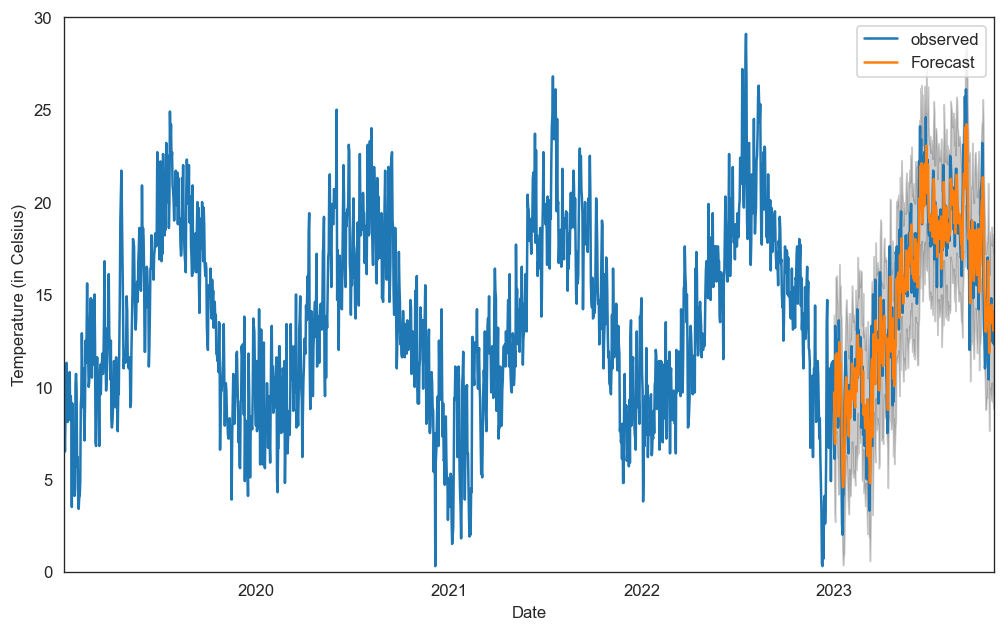

In [90]:
#plotting the actual and forecasted data from the model having least AIC score
ax = one_step_df.T_mu_actual['2019':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='Forecast')

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (in Celsius)')
plt.ylim([0,30])
plt.legend()
plt.show()

In [91]:
sarima_forecasted = pred.predicted_mean
sarima_actual = one_step_df.T_mu_actual['2023-01-01':]
print(sarima_forecasted.shape)
print(sarima_actual.shape)
# Compute the mean square error
mse = mean_squared_error(sarima_actual, sarima_forecasted)

print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

(304,)
(304,)
The Mean Squared Error of our forecasts is 4.37


In [92]:
#calculating the performance of the model
sarima_mae  = mean_absolute_error(sarima_actual,sarima_forecasted)
sarima_mse  = (mean_squared_error(sarima_actual, sarima_forecasted)).round(2)
sarima_rmse = np.sqrt(mean_squared_error(sarima_actual, sarima_forecasted)).round(2)
sarima_mape = np.round(np.mean(np.abs(sarima_actual-sarima_forecasted)/sarima_actual)*100,2)


results_sarima = pd.DataFrame({'Method':['SARIMA'],'MAE': [sarima_mae],'MSE': [sarima_mse] ,'MAPE': [sarima_mape], 'RMSE': [sarima_rmse]})
results_sarima = results_sarima[['Method','MAE' ,'MSE','RMSE', 'MAPE']]
results_sarima

,Method,MAE,MSE,RMSE,MAPE
0,SARIMA,1.620551,4.37,2.09,13.3
